In [1]:
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from CMAPSSDataset import *
import CMAPSSDataset as cmap
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Usando: cuda
GPU: NVIDIA GeForce RTX 2060
VRAM disponible: 6.4 GB


## GRN

In [2]:
class GatedResidualNetwork(nn.Module):
    """
    Bloque fundamental del TFT.

    Parámetros:
        input_dim   — dimensión de la entrada principal
        hidden_dim  — dimensión del espacio interno de procesamiento
        output_dim  — dimensión de la salida
        dropout     — regularización
        context_dim — dimensión del contexto externo (opcional)
                      se usa cuando el GRN recibe información adicional
                      por ejemplo: variables estáticas condicionando
                      el procesamiento de variables dinámicas
    """
    def __init__(self, input_dim, hidden_dim, output_dim,
                 dropout=0.1, context_dim=None):
        super().__init__()

        # ── Componente 1: transformación no lineal ───────────────────────
        # Dos capas lineales con ELU entre ellas
        # ELU en lugar de ReLU porque no mata gradientes en valores negativos
        self.linear_1 = nn.Linear(input_dim, hidden_dim)
        self.linear_2 = nn.Linear(hidden_dim, output_dim)

        # ── Componente 2: contexto externo (opcional) ────────────────────
        # Si llega contexto, se suma ANTES de la primera activación
        # Así el contexto puede modular cómo se procesa la entrada
        self.context_projection = nn.Linear(context_dim, hidden_dim,
                                            bias=False) \
                                  if context_dim is not None else None

        # ── Componente 3: gate (GLU — Gated Linear Unit) ─────────────────
        # Produce dos vectores del mismo tamaño:
        #   - uno pasa por sigmoid → valores entre 0 y 1 (el gate)
        #   - el otro se multiplica por el gate → filtra la información
        # Efecto: cada dimensión de la salida puede ser bloqueada (0)
        #         o dejada pasar (1) de forma aprendida
        self.gate = nn.Linear(output_dim, output_dim * 2)

        # ── Componente 4: proyección residual ────────────────────────────
        # Si input_dim != output_dim necesitamos proyectar para poder sumar
        # Si son iguales, la entrada pasa directamente (identidad)
        self.residual_projection = nn.Linear(input_dim, output_dim,
                                             bias=False) \
                                   if input_dim != output_dim else None

        # ── Componente 5: normalización y regularización ─────────────────
        self.layer_norm = nn.LayerNorm(output_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, context=None):
        """
        x:       (batch, ..., input_dim)   — entrada principal
        context: (batch, ..., context_dim) — contexto externo (opcional)

        Los '...' pueden ser una dimensión temporal (batch, T, dim)
        o nada (batch, dim) — el GRN funciona igual en ambos casos
        """

        # ── Paso 1: transformación no lineal ─────────────────────────────
        h = self.linear_1(x)                    # (batch, ..., hidden_dim)

        # Inyectar contexto si existe
        # El contexto modula la transformación desde el principio
        if context is not None and self.context_projection is not None:
            h = h + self.context_projection(context)

        h = F.elu(h)                            # activación suave
        h = self.linear_2(h)                    # (batch, ..., output_dim)
        h = self.dropout(h)

        # ── Paso 2: gate (GLU) ────────────────────────────────────────────
        # gate produce output_dim*2 valores
        # los primeros output_dim son los valores
        # los segundos output_dim son las compuertas
        gate_input  = self.gate(h)
        values, gates = gate_input.chunk(2, dim=-1)
        # chunk divide el tensor en 2 partes iguales por la última dimensión
        h = values * torch.sigmoid(gates)       # (batch, ..., output_dim)
        # cada dimensión se multiplica por un valor entre 0 y 1
        # el modelo aprende qué dimensiones dejar pasar

        # ── Paso 3: conexión residual + normalización ─────────────────────
        # Proyectar la entrada si las dimensiones no coinciden
        residual = self.residual_projection(x) \
                   if self.residual_projection is not None else x

        out = self.layer_norm(residual + h)     # (batch, ..., output_dim)
        # LayerNorm después de la suma residual — igual que en transformers

        return out

## GRN Test

In [3]:
# ── Caso 1: sin contexto, misma dimensión entrada/salida ─────────────────
grn_simple = GatedResidualNetwork(
    input_dim  = 64,
    hidden_dim = 64,
    output_dim = 64,
    dropout    = 0.1
)
x      = torch.randn(32, 30, 64)   # (batch, timesteps, features)
salida = grn_simple(x)
print(f"Caso 1 — entrada: {x.shape} → salida: {salida.shape}")
# esperado: torch.Size([32, 30, 64])

# ── Caso 2: con contexto externo ─────────────────────────────────────────
grn_context = GatedResidualNetwork(
    input_dim   = 64,
    hidden_dim  = 64,
    output_dim  = 64,
    dropout     = 0.1,
    context_dim = 32    # contexto de dimensión distinta
)
x       = torch.randn(32, 30, 64)
context = torch.randn(32, 30, 32)  # mismo shape temporal que x
salida  = grn_context(x, context)
print(f"Caso 2 — entrada: {x.shape} contexto: {context.shape} → salida: {salida.shape}")
# esperado: torch.Size([32, 30, 64])

# ── Caso 3: proyección residual — dimensiones distintas ──────────────────
grn_proj = GatedResidualNetwork(
    input_dim  = 59,    # n_features del dataset
    hidden_dim = 64,
    output_dim = 64,    # distinto a input_dim → activa residual_projection
    dropout    = 0.1
)
x      = torch.randn(32, 30, 59)
salida = grn_proj(x)
print(f"Caso 3 — entrada: {x.shape} → salida: {salida.shape}")
# esperado: torch.Size([32, 30, 64])

# ── Caso 4: sin dimensión temporal (para variables estáticas) ─────────────
grn_static = GatedResidualNetwork(
    input_dim  = 32,
    hidden_dim = 32,
    output_dim = 32,
    dropout    = 0.1
)
x      = torch.randn(32, 32)   # sin dimensión temporal
salida = grn_static(x)
print(f"Caso 4 — entrada: {x.shape} → salida: {salida.shape}")
# esperado: torch.Size([32, 32])

# ── Verificar que el gate realmente filtra ────────────────────────────────
grn_test = GatedResidualNetwork(64, 64, 64).eval()
with torch.no_grad():
    x1 = torch.randn(1, 64)
    x2 = torch.zeros(1, 64)    # entrada de ceros
    s1 = grn_test(x1)
    s2 = grn_test(x2)
    print(f"\nNorma salida con entrada normal: {s1.norm():.4f}")
    print(f"Norma salida con entrada ceros:  {s2.norm():.4f}")
    # Con entrada ceros el residual pasa casi sin cambios
    # la salida debería tener norma cercana a 0 (LayerNorm de ceros)

Caso 1 — entrada: torch.Size([32, 30, 64]) → salida: torch.Size([32, 30, 64])
Caso 2 — entrada: torch.Size([32, 30, 64]) contexto: torch.Size([32, 30, 32]) → salida: torch.Size([32, 30, 64])
Caso 3 — entrada: torch.Size([32, 30, 59]) → salida: torch.Size([32, 30, 64])
Caso 4 — entrada: torch.Size([32, 32]) → salida: torch.Size([32, 32])

Norma salida con entrada normal: 8.0000
Norma salida con entrada ceros:  7.9795


## VSN

In [4]:
class VariableSelectionNetwork(nn.Module):
    """
    Aprende qué variables son más relevantes en cada timestep.

    Parámetros:
        input_dim    — dimensión de cada variable de entrada (tras embedding)
        num_vars     — número total de variables
        hidden_dim   — dimensión del espacio interno
        dropout      — regularización
        context_dim  — dimensión del contexto externo (opcional)
                       permite que variables estáticas modulen
                       la selección de variables dinámicas
    """
    def __init__(self, input_dim, num_vars, hidden_dim,
                 dropout=0.1, context_dim=None):
        super().__init__()

        self.num_vars  = num_vars
        self.hidden_dim = hidden_dim

        # ── Nivel 1: un GRN por variable ─────────────────────────────────
        # Cada variable tiene su propio GRN para aprender
        # una representación individual independiente de las demás
        # ModuleList porque el número de variables es dinámico
        self.var_grns = nn.ModuleList([
            GatedResidualNetwork(
                input_dim   = input_dim,
                hidden_dim  = hidden_dim,
                output_dim  = hidden_dim,
                dropout     = dropout
            )
            for _ in range(num_vars)
        ])

        # ── Nivel 2: GRN para calcular pesos de importancia ───────────────
        # Recibe TODAS las variables concatenadas
        # Produce un vector de num_vars pesos
        # El contexto entra aquí — modula qué variables importan
        # según la información estática del motor
        self.weight_grn = GatedResidualNetwork(
            input_dim   = input_dim * num_vars,  # todas las vars concatenadas
            hidden_dim  = hidden_dim,
            output_dim  = num_vars,              # un peso por variable
            dropout     = dropout,
            context_dim = context_dim
        )

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, context=None):
        """
        x:       (batch, timesteps, num_vars, input_dim)
                 cada variable ya viene con su propia dimensión
        context: (batch, timesteps, context_dim) — opcional

        Salida:
            combined:  (batch, timesteps, hidden_dim)
                       representación combinada ponderada por importancia
            weights:   (batch, timesteps, num_vars)
                       importancia de cada variable en cada timestep
                       directamente interpretable — esto es lo que
                       aparecerá en los gráficos del paper
        """
        batch_size = x.shape[0]
        timesteps  = x.shape[1]

        # ── Nivel 1: procesar cada variable por su GRN individual ─────────
        var_representations = []
        for i, grn in enumerate(self.var_grns):
            # x[:, :, i, :] → (batch, timesteps, input_dim)
            # cada variable se procesa de forma independiente
            var_out = grn(x[:, :, i, :])          # (batch, T, hidden_dim)
            var_representations.append(var_out)

        # Apilar todas las representaciones
        # (batch, T, hidden_dim) × num_vars → (batch, T, num_vars, hidden_dim)
        stacked = torch.stack(var_representations, dim=2)

        # ── Nivel 2: calcular pesos de importancia ────────────────────────
        # Aplanar todas las variables para el GRN de pesos
        # (batch, T, num_vars, input_dim) → (batch, T, num_vars * input_dim)
        x_flat   = x.reshape(batch_size, timesteps, -1)
        weights  = self.weight_grn(x_flat, context)  # (batch, T, num_vars)
        weights  = self.softmax(weights)              # suma 1 por timestep

        # ── Combinación final: suma ponderada ─────────────────────────────
        # weights: (batch, T, num_vars)     → (batch, T, num_vars, 1)
        # stacked: (batch, T, num_vars, hidden_dim)
        weights_expanded = weights.unsqueeze(-1)      # (batch, T, num_vars, 1)
        combined = (stacked * weights_expanded).sum(dim=2)
        # (batch, T, num_vars, hidden_dim) * (batch, T, num_vars, 1)
        # → suma sobre dim=2 → (batch, T, hidden_dim)

        return combined, weights

In [5]:
class FeatureProjection(nn.Module):
    """
    Proyecta cada feature escalar a un vector de dimensión input_dim.
    Convierte (batch, T, n_features) → (batch, T, n_features, input_dim)

    Esto es análogo a los embeddings en NLP — cada token (feature)
    tiene su propio vector de representación en lugar de ser un escalar.
    """
    def __init__(self, n_features, input_dim):
        super().__init__()
        # Una capa lineal por feature — cada una aprende
        # su propia proyección al espacio de input_dim dimensiones
        self.projections = nn.ModuleList([
            nn.Linear(1, input_dim)
            for _ in range(n_features)
        ])

    def forward(self, x):
        # x: (batch, T, n_features)
        projected = []
        for i, proj in enumerate(self.projections):
            # x[:, :, i:i+1] → (batch, T, 1) — feature i como vector columna
            projected.append(proj(x[:, :, i:i+1]))  # (batch, T, input_dim)

        # Apilar → (batch, T, n_features, input_dim)
        return torch.stack(projected, dim=2)

## VSN Vectorizado

In [6]:
class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, num_vars, hidden_dim,
                 dropout=0.1, context_dim=None):
        super().__init__()
        self.num_vars   = num_vars
        self.hidden_dim = hidden_dim
        self.input_dim  = input_dim

        # Conv1d con groups=num_vars — pesos independientes por variable
        # pero operación vectorizada en GPU sin bucle Python
        self.var_linear1 = nn.Conv1d(
            num_vars * input_dim, num_vars * hidden_dim,
            kernel_size=1, groups=num_vars
        )
        self.var_linear2 = nn.Conv1d(
            num_vars * hidden_dim, num_vars * hidden_dim,
            kernel_size=1, groups=num_vars
        )
        self.var_gate = nn.Conv1d(
            num_vars * hidden_dim, num_vars * hidden_dim * 2,
            kernel_size=1, groups=num_vars
        )
        self.var_residual = nn.Conv1d(
            num_vars * input_dim, num_vars * hidden_dim,
            kernel_size=1, groups=num_vars, bias=False
        ) if input_dim != hidden_dim else None

        self.var_norm    = nn.LayerNorm(hidden_dim)
        self.var_dropout = nn.Dropout(dropout)

        self.weight_grn = GatedResidualNetwork(
            input_dim   = input_dim * num_vars,
            hidden_dim  = hidden_dim,
            output_dim  = num_vars,
            dropout     = dropout,
            context_dim = context_dim
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, context=None):
        # x: (batch, T, num_vars, input_dim)
        batch, T, V, D = x.shape

        # ── Reshape para Conv1d ───────────────────────────────────────────
        # Conv1d espera (N, C, L) → usamos L=1, C=V*D
        x_conv = x.reshape(batch * T, V * D, 1)

        # ── GRN vectorizado por variable ──────────────────────────────────
        h = F.elu(self.var_linear1(x_conv))      # (batch*T, V*hidden, 1)
        h = self.var_linear2(h)
        h = self.var_dropout(h)

        # GLU
        values, gates = self.var_gate(h).chunk(2, dim=1)
        h = values * torch.sigmoid(gates)         # (batch*T, V*hidden, 1)

        # Residual
        res = self.var_residual(x_conv) if self.var_residual else x_conv
        h = h + res

        # LayerNorm — reshape a (batch*T*V, hidden) para que actúe por var
        h = h.squeeze(-1).reshape(batch * T * V, self.hidden_dim)
        h = self.var_norm(h)

        # ── Suma ponderada — sin materializar (batch,T,V,hidden) ──────────
        # h: (batch*T*V, hidden) → (batch, T, V, hidden)
        h = h.reshape(batch, T, V, self.hidden_dim)

        # Pesos de importancia
        x_concat = x.reshape(batch, T, -1)        # (batch, T, V*input_dim)
        weights  = self.softmax(
            self.weight_grn(x_concat, context)
        )                                          # (batch, T, V)

        # Suma ponderada con einsum — evita broadcast explícito
        # (batch, T, V, hidden) × (batch, T, V) → (batch, T, hidden)
        combined = torch.einsum("btvh,btv->bth", h, weights)

        return combined, weights

## VSN Test

In [7]:
# Parámetros de prueba alineados con CMAPSS FD001
batch_size = 32
timesteps  = 60
n_features = 59    # features de FD001 tras eliminar constantes
input_dim  = 16    # dimensión de proyección por feature
hidden_dim = 64    # dimensión interna del VSN

# ── Paso 1: proyectar features escalares a vectores ───────────────────────
feature_proj = FeatureProjection(n_features, input_dim)
x_raw  = torch.randn(batch_size, timesteps, n_features)
x_proj = feature_proj(x_raw)
print(f"Tras proyección: {x_raw.shape} → {x_proj.shape}")
# esperado: torch.Size([32, 60, 59, 16])

# ── Paso 2: pasar por el VSN ──────────────────────────────────────────────
vsn = VariableSelectionNetwork(
    input_dim  = input_dim,
    num_vars   = n_features,
    hidden_dim = hidden_dim,
    dropout    = 0.1
)
combined, weights = vsn(x_proj)
print(f"Salida VSN:      {combined.shape}")
print(f"Pesos VSN:       {weights.shape}")
# esperado: torch.Size([32, 60, 64])
#           torch.Size([32, 60, 59])

# ── Paso 3: verificar que los pesos suman 1 ───────────────────────────────
suma_pesos = weights.sum(dim=-1)
print(f"Suma pesos (debe ser 1.0): {suma_pesos[0, 0].item():.6f}")

# ── Paso 4: VSN con contexto externo ─────────────────────────────────────
# Simular variables estáticas del motor como contexto
# por ejemplo: qué dataset es, condición operacional predominante
context_dim = 32
vsn_ctx = VariableSelectionNetwork(
    input_dim   = input_dim,
    num_vars    = n_features,
    hidden_dim  = hidden_dim,
    dropout     = 0.1,
    context_dim = context_dim
)
context  = torch.randn(batch_size, timesteps, context_dim)
combined_ctx, weights_ctx = vsn_ctx(x_proj, context)
print(f"\nCon contexto:")
print(f"Salida VSN: {combined_ctx.shape}")
print(f"Pesos VSN:  {weights_ctx.shape}")

# ── Paso 5: ver la distribución de pesos ─────────────────────────────────
# Con pesos aleatorios debería ser casi uniforme (1/59 ≈ 0.017)
# Tras entrenamiento algunos sensores tendrán pesos mucho más altos
peso_medio   = weights[0, 0].mean().item()
peso_max     = weights[0, 0].max().item()
peso_min     = weights[0, 0].min().item()
print(f"\nDistribución pesos (pesos aleatorios, sin entrenar):")
print(f"  Media:  {peso_medio:.4f}  (uniforme sería {1/n_features:.4f})")
print(f"  Máximo: {peso_max:.4f}")
print(f"  Mínimo: {peso_min:.4f}")

Tras proyección: torch.Size([32, 60, 59]) → torch.Size([32, 60, 59, 16])
Salida VSN:      torch.Size([32, 60, 64])
Pesos VSN:       torch.Size([32, 60, 59])
Suma pesos (debe ser 1.0): 1.000000

Con contexto:
Salida VSN: torch.Size([32, 60, 64])
Pesos VSN:  torch.Size([32, 60, 59])

Distribución pesos (pesos aleatorios, sin entrenar):
  Media:  0.0169  (uniforme sería 0.0169)
  Máximo: 0.1074
  Mínimo: 0.0013


## LSTM Encoder

In [8]:
class LSTMEncoder(nn.Module):
    """
    Procesa la secuencia del VSN y produce:
      - sequence_out : todos los estados ocultos → va a la atención
      - context      : estado final comprimido  → inicializa GRNs posteriores

    Parámetros:
        input_dim   — dimensión de entrada (= hidden_dim del VSN)
        hidden_dim  — dimensión del estado oculto del LSTM
        num_layers  — capas apiladas (2 es suficiente para CMAPSS)
        dropout     — dropout entre capas (solo actúa si num_layers > 1)
    """
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.1):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM unidireccional con num_layers > 1
        # así el dropout interno sí funciona (a diferencia del CNN-BiLSTM)
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # GRN para comprimir el estado final en un context vector
        # El estado final h_n tiene forma (num_layers, batch, hidden_dim)
        # Solo usamos la última capa → (batch, hidden_dim)
        # El GRN lo transforma en una representación más rica
        self.context_grn = GatedResidualNetwork(
            input_dim  = hidden_dim,
            hidden_dim = hidden_dim,
            output_dim = hidden_dim,
            dropout    = dropout
        )

    def forward(self, x):
        """
        x: (batch, timesteps, input_dim)  ← salida del VSN

        Devuelve:
            sequence_out : (batch, timesteps, hidden_dim)
                           todos los estados ocultos — para la atención
            context      : (batch, hidden_dim)
                           resumen del estado final — para los GRNs
        """
        # El LSTM procesa la secuencia completa de una vez
        # sequence_out contiene h_t para cada t=1..T
        # (h_n, c_n) son solo el último timestep
        sequence_out, (h_n, c_n) = self.lstm(x)
        # sequence_out: (batch, T, hidden_dim)
        # h_n:          (num_layers, batch, hidden_dim)
        # c_n:          (num_layers, batch, hidden_dim)

        # Tomar solo la última capa del estado oculto final
        # h_n[-1] → (batch, hidden_dim)
        context = self.context_grn(h_n[-1])
        # context: (batch, hidden_dim)
        # este vector resume toda la secuencia en un punto
        # se usará para condicionar la atención y los GRNs posteriores

        return sequence_out, context

## LSTM Test

In [9]:
batch_size = 32
timesteps  = 60
vsn_dim    = 64    # hidden_dim del VSN
lstm_dim   = 64    # hidden_dim del encoder

encoder = LSTMEncoder(
    input_dim  = vsn_dim,
    hidden_dim = lstm_dim,
    num_layers = 2,
    dropout    = 0.1
)

# Simular salida del VSN
vsn_output = torch.randn(batch_size, timesteps, vsn_dim)

sequence_out, context = encoder(vsn_output)

print(f"Entrada VSN:    {vsn_output.shape}")
print(f"Secuencia LSTM: {sequence_out.shape}")
print(f"Context vector: {context.shape}")
# esperado:
# Entrada VSN:    torch.Size([32, 60, 64])
# Secuencia LSTM: torch.Size([32, 60, 64])
# Context vector: torch.Size([32, 64])

# Verificar que el context vector es distinto para distintas entradas
# (el GRN no debe colapsar todo al mismo vector)
vsn_output_2   = torch.randn(batch_size, timesteps, vsn_dim)
_, context_2   = encoder(vsn_output_2)
diferencia     = (context - context_2).abs().mean().item()
print(f"\nDiferencia media entre dos context vectors: {diferencia:.4f}")
# debe ser > 0 — si fuera 0 el encoder ignoraría la entrada

Entrada VSN:    torch.Size([32, 60, 64])
Secuencia LSTM: torch.Size([32, 60, 64])
Context vector: torch.Size([32, 64])

Diferencia media entre dos context vectors: 0.4431


## Multi-Headed Attention

In [10]:
class TemporalSelfAttention(nn.Module):
    """
    Multi-head self-attention sobre la secuencia del LSTM encoder.
    Cada timestep atiende a todos los demás timesteps.

    En el TFT original se añade una máscara causal (solo hacia el pasado).
    Para RUL en CMAPSS donde tienes la ventana completa disponible,
    la máscara es opcional — sin ella el modelo ve toda la ventana.

    Parámetros:
        hidden_dim  — dimensión de entrada y salida
        num_heads   — número de cabezas de atención en paralelo
                      hidden_dim debe ser divisible por num_heads
        dropout     — dropout sobre los pesos de atención
    """
    def __init__(self, hidden_dim, num_heads=4, dropout=0.1):
        super().__init__()

        assert hidden_dim % num_heads == 0, \
            f"hidden_dim ({hidden_dim}) debe ser divisible por num_heads ({num_heads})"

        self.hidden_dim = hidden_dim
        self.num_heads  = num_heads
        self.head_dim   = hidden_dim // num_heads  # dimensión por cabeza

        # PyTorch tiene MultiheadAttention nativo — lo reutilizamos
        # batch_first=True para que acepte (batch, T, dim)
        self.attention = nn.MultiheadAttention(
            embed_dim   = hidden_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )

        # GRN post-atención — decide cuánta información de la atención
        # es útil y cuánta descartar mediante el gate
        self.post_attention_grn = GatedResidualNetwork(
            input_dim  = hidden_dim,
            hidden_dim = hidden_dim,
            output_dim = hidden_dim,
            dropout    = dropout
        )

        # LayerNorm para la conexión residual
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, mask=None):
        """
        x:    (batch, T, hidden_dim)  ← sequence_out del LSTM encoder
        mask: (T, T) opcional         ← máscara causal si quieres
                                        que t solo vea t' <= t

        Devuelve:
            output:       (batch, T, hidden_dim)
                          cada timestep enriquecido con contexto global
            attn_weights: (batch, T, T)
                          peso que cada timestep da a cada otro
                          directamente interpretable — muestra qué
                          ciclos se "miran" entre sí
        """
        # Self-attention: Q, K, V son todos la misma secuencia x
        # el modelo aprende qué parte de x es útil como Query,
        # Key y Value mediante las proyecciones internas de nn.MultiheadAttention
        attn_out, attn_weights = self.attention(
            query = x,
            key   = x,
            value = x,
            attn_mask = mask,
            need_weights = True,    # devolver los pesos para visualización
            average_attn_weights = False  # mantener pesos por cabeza
        )
        # attn_out:     (batch, T, hidden_dim)
        # attn_weights: (batch, num_heads, T, T)

        # Conexión residual + LayerNorm
        # igual que en los transformers originales
        x = self.layer_norm(x + attn_out)

        # GRN post-atención — filtra información no útil
        output = self.post_attention_grn(x)

        return output, attn_weights

## Attention test

In [11]:
batch_size = 32
timesteps  = 60
hidden_dim = 64
num_heads  = 4     # 64 / 4 = 16 dims por cabeza

attention_layer = TemporalSelfAttention(
    hidden_dim = hidden_dim,
    num_heads  = num_heads,
    dropout    = 0.1
)

# Simular salida del LSTM encoder
lstm_output = torch.randn(batch_size, timesteps, hidden_dim)

output, attn_weights = attention_layer(lstm_output)

print(f"Entrada LSTM:     {lstm_output.shape}")
print(f"Salida atención:  {output.shape}")
print(f"Pesos atención:   {attn_weights.shape}")
# esperado:
# Entrada LSTM:     torch.Size([32, 60, 64])
# Salida atención:  torch.Size([32, 60, 64])
# Pesos atención:   torch.Size([32, 4, 60, 60])
#                              batch cabezas T   T

# Siempre que verifiques shapes o valores, usa eval() + no_grad()
attention_layer.eval()
with torch.no_grad():
    output, attn_weights = attention_layer(lstm_output)

suma = attn_weights[0, 0].sum(dim=-1)
print(f"Suma pesos por fila: {suma[:3]}")
# ahora sí: tensor([1.0000, 1.0000, 1.0000])

# Volver a modo entrenamiento cuando termines de verificar
attention_layer.train()

Entrada LSTM:     torch.Size([32, 60, 64])
Salida atención:  torch.Size([32, 60, 64])
Pesos atención:   torch.Size([32, 4, 60, 60])
Suma pesos por fila: tensor([1.0000, 1.0000, 1.0000])


TemporalSelfAttention(
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (post_attention_grn): GatedResidualNetwork(
    (linear_1): Linear(in_features=64, out_features=64, bias=True)
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
    (gate): Linear(in_features=64, out_features=128, bias=True)
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

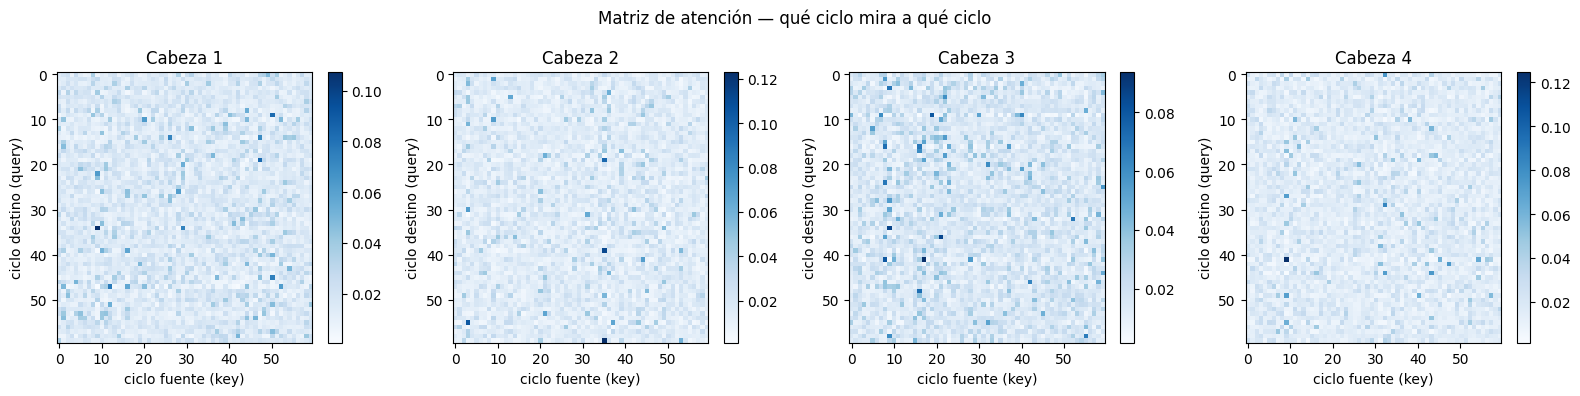

In [12]:
# Visualizar la matriz de atención tras entrenar
# (con pesos aleatorios no es informativo, pero la estructura es correcta)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h, ax in enumerate(axes):
    # attn_weights: (batch, num_heads, T, T)
    matriz = attn_weights[0, h].detach().numpy()  # primer motor, cabeza h
    im = ax.imshow(matriz, aspect="auto", cmap="Blues")
    ax.set_title(f"Cabeza {h+1}")
    ax.set_xlabel("ciclo fuente (key)")
    ax.set_ylabel("ciclo destino (query)")
    plt.colorbar(im, ax=ax)

plt.suptitle("Matriz de atención — qué ciclo mira a qué ciclo")
plt.tight_layout()
plt.show()

# Tras entrenar buscarás estos patrones:
# Cabeza 1 → diagonal fuerte: cada ciclo mira a sus vecinos cercanos
# Cabeza 2 → última fila fuerte: los ciclos finales miran al historial
# Cabeza 3 → bloques: agrupa ciclos de degradación similar
# Cabeza 4 → columna fuerte en un ciclo: punto de inflexión de degradación

## Regression with Quantil Uncertainty

In [13]:
class QuantileRegressionHead(nn.Module):
    """
    Cabeza de regresión con cuantiles para el TFT.

    Colapsa la secuencia de atención en una predicción de RUL
    con tres cuantiles: p10 (optimista), p50 (mediana), p90 (pesimista).

    Parámetros:
        hidden_dim  — dimensión de entrada (= hidden_dim de la atención)
        quantiles   — lista de cuantiles a predecir
        dropout     — regularización
    """
    def __init__(self, hidden_dim, quantiles=[0.1, 0.5, 0.9], dropout=0.1):
        super().__init__()

        self.quantiles  = quantiles
        self.n_quantiles = len(quantiles)

        # Un GRN + Linear por cuantil para separarlos
        self.heads = nn.ModuleList([
            nn.Sequential(
                GatedResidualNetwork(
                    input_dim = hidden_dim,
                    hidden_dim = hidden_dim,
                    output_dim = hidden_dim,
                    dropout = dropout,
                    context_dim = hidden_dim
                ),
                nn.Linear(hidden_dim,1)
            )
            for _ in self.quantiles
        ])

    def forward(self, attn_output, context):
        """
        attn_output: (batch, T, hidden_dim)  ← salida de la atención
        context:     (batch, hidden_dim)     ← context vector del encoder

        Devuelve:
            quantiles: (batch, n_quantiles)
                       [RUL_p10, RUL_p50, RUL_p90] por motor
        """
        # Colapsar la dimensión temporal
        # usamos el último timestep — contiene el estado más reciente
        # y ya tiene contexto global gracias a la atención
        x = attn_output[:, -1, :]       # (batch, hidden_dim)

        preds = []
        for head in self.heads:
            grn, linear = head[0], head[1]
            h = grn(x, context) # (batch, hidden_dim)
            preds.append(linear(h)) # (batch, 1)

        return torch.cat(preds, dim=1) # (batch, n_quantiles)


# ── Función de pérdida: Quantile Loss (Pinball Loss) ─────────────────────

def quantile_loss(y_pred, y_true, quantiles=[0.1, 0.5, 0.9]):
    """
    Pérdida de cuantiles (Pinball Loss).

    Para cada cuantil q:
      - si y_true > y_pred: penaliza con q        × error
      - si y_true < y_pred: penaliza con (1-q)    × error

    Efecto:
      q=0.1 → penaliza más las predicciones ALTAS que las bajas
              el modelo aprende a predecir el percentil 10
      q=0.5 → penaliza igual en ambos lados → mediana
      q=0.9 → penaliza más las predicciones BAJAS que las altas
              el modelo aprende a predecir el percentil 90

    y_pred: (batch, n_quantiles)
    y_true: (batch,)
    """
    losses = []

    for i, q in enumerate(quantiles):
        pred_q = y_pred[:, i]              # predicción del cuantil q
        error  = y_true - pred_q           # error: positivo si subestimamos

        # Pérdida asimétrica por cuantil
        loss_q = torch.where(
            error >= 0,
            q * error,           # subestimación: penalizar con q
            (q - 1) * error      # sobreestimación: penalizar con (1-q)
        )
        losses.append(loss_q.mean())

    return torch.stack(losses).mean()

## Regression Test

In [14]:
batch_size  = 32
hidden_dim  = 64
quantiles   = [0.1, 0.5, 0.9]

head = QuantileRegressionHead(
    hidden_dim = hidden_dim,
    quantiles  = quantiles,
    dropout    = 0.1
)

# Simular salidas de la atención y el context vector
attn_output = torch.randn(batch_size, 60, hidden_dim)
context     = torch.randn(batch_size, hidden_dim)

head.eval()
with torch.no_grad():
    preds = head(attn_output, context)

print(f"Salida cuantiles: {preds.shape}")
# esperado: torch.Size([32, 3])

# Verificar que p10 < p50 < p90 para cada motor
# con pesos aleatorios no se cumple todavía — se aprende durante el entrenamiento
p10, p50, p90 = preds[:, 0], preds[:, 1], preds[:, 2]
ordenados = (p10 < p50).all() and (p50 < p90).all()
print(f"p10 < p50 < p90 (pesos aleatorios): {ordenados}")
# False con pesos aleatorios — True tras entrenar

# Verificar la función de pérdida
y_true = torch.rand(batch_size) * 125   # RUL entre 0 y 125
loss   = quantile_loss(preds, y_true, quantiles)
print(f"Quantile loss: {loss.item():.4f}")

# Verificar asimetría de la pérdida
# para q=0.9, subestimar debe costar más que sobreestimar
y_true_test = torch.tensor([50.0])
pred_bajo   = torch.tensor([[50.0, 40.0, 30.0]])  # subestimando el p90
pred_alto   = torch.tensor([[70.0, 60.0, 60.0]])  # sobreestimando el p90
loss_bajo   = quantile_loss(pred_bajo,  y_true_test, quantiles)
loss_alto   = quantile_loss(pred_alto,  y_true_test, quantiles)
print(f"\nAsimetría de la pérdida:")
print(f"  Subestimar (pred_p90=30 < real=50): {loss_bajo.item():.4f}")
print(f"  Sobreestimar (pred_p90=60 > real=50): {loss_alto.item():.4f}")
print(f"  Subestimar cuesta más: {loss_bajo > loss_alto}")

Salida cuantiles: torch.Size([32, 3])
p10 < p50 < p90 (pesos aleatorios): False
Quantile loss: 28.9016

Asimetría de la pérdida:
  Subestimar (pred_p90=30 < real=50): 7.6667
  Sobreestimar (pred_p90=60 > real=50): 8.0000
  Subestimar cuesta más: False


## TFT Builder

In [15]:
class TemporalFusionTransformer(nn.Module):
    """
    TFT adaptado para regresión de RUL en CMAPSS.

    Adaptaciones respecto al paper original (Lim et al. 2021):
      - Sin variables conocidas en el futuro (no hay decoder separado)
      - Cabeza de regresión con cuantiles en lugar de forecasting multi-horizonte
      - VSN unificado para variables dinámicas (sensores + config. operacional)
      - Variables estáticas opcionales (dataset ID, condición operacional)

    Parámetros:
        n_features      — número de features de entrada (sensores + derivadas + op)
        hidden_dim      — dimensión interna de todos los bloques
        num_heads       — cabezas de atención (hidden_dim debe ser divisible)
        num_lstm_layers — capas del encoder LSTM
        dropout         — regularización global
        quantiles       — cuantiles a predecir
        static_dim      — dimensión de variables estáticas opcionales
                          si es None no se usan variables estáticas
    """
    def __init__(
        self,
        n_features,
        hidden_dim      = 64,
        num_heads       = 4,
        num_lstm_layers = 2,
        dropout         = 0.1,
        quantiles       = [0.1, 0.5, 0.9],
        static_dim      = None
    ):
        super().__init__()

        self.hidden_dim  = hidden_dim
        self.quantiles   = quantiles
        self.use_static  = static_dim is not None

        # ── Bloque 1: proyección de features escalares a vectores ─────────
        # cada feature escalar → vector de hidden_dim // 4 dimensiones
        # hidden_dim // 4 es el input_dim del VSN
        self.input_dim = hidden_dim // 4   # 16 si hidden_dim=64
        self.feature_projection = FeatureProjection(
            n_features = n_features,
            input_dim  = self.input_dim
        )

        # ── Bloque 2: Variable Selection Network ─────────────────────────
        # context_dim = hidden_dim si hay variables estáticas
        # las variables estáticas condicionan qué sensores importan
        self.vsn = VariableSelectionNetwork(
            input_dim   = self.input_dim,
            num_vars    = n_features,
            hidden_dim  = hidden_dim,
            dropout     = dropout,
            context_dim = hidden_dim if self.use_static else None
        )

        # ── Variables estáticas (opcionales) ─────────────────────────────
        # si se usan, se proyectan al espacio hidden_dim
        # y se pasan como contexto al VSN y al encoder
        if self.use_static:
            self.static_grn = GatedResidualNetwork(
                input_dim  = static_dim,
                hidden_dim = hidden_dim,
                output_dim = hidden_dim,
                dropout    = dropout
            )

        # ── Bloque 3: LSTM encoder ────────────────────────────────────────
        self.encoder = LSTMEncoder(
            input_dim   = hidden_dim,
            hidden_dim  = hidden_dim,
            num_layers  = num_lstm_layers,
            dropout     = dropout
        )

        # ── Bloque 4: atención multi-cabezal temporal ─────────────────────
        self.attention = TemporalSelfAttention(
            hidden_dim = hidden_dim,
            num_heads  = num_heads,
            dropout    = dropout
        )

        # GRN entre encoder y atención
        # enriquece la secuencia antes de la atención
        self.pre_attention_grn = GatedResidualNetwork(
            input_dim   = hidden_dim,
            hidden_dim  = hidden_dim,
            output_dim  = hidden_dim,
            dropout     = dropout,
            context_dim = hidden_dim   # condicionado por context del encoder
        )

        # ── Bloque 5: cabeza de regresión con cuantiles ───────────────────
        self.head = QuantileRegressionHead(
            hidden_dim = hidden_dim,
            quantiles  = quantiles,
            dropout    = dropout
        )

    def forward(self, x, static=None):
        """
        x:      (batch, T, n_features)   ← ventana de ciclos
        static: (batch, static_dim)      ← variables estáticas opcionales
                                           por ejemplo: one-hot del dataset,
                                           condición operacional predominante

        Devuelve:
            quantiles:    (batch, n_quantiles)  ← [p10, p50, p90]
            vsn_weights:  (batch, T, n_features) ← importancia por sensor
            attn_weights: (batch, heads, T, T)  ← qué ciclos se atienden
        """
        # ── Paso 1: proyectar features escalares ─────────────────────────
        x_proj = self.feature_projection(x)
        # (batch, T, n_features) → (batch, T, n_features, input_dim)

        # ── Paso 2: procesar variables estáticas si existen ───────────────
        static_context = None
        if self.use_static and static is not None:
            static_context = self.static_grn(static)
            # (batch, static_dim) → (batch, hidden_dim)

            # expandir para que tenga dimensión temporal
            # el VSN necesita (batch, T, hidden_dim) como contexto
            static_context_seq = static_context.unsqueeze(1).expand(
                -1, x.shape[1], -1
            )
            # (batch, hidden_dim) → (batch, T, hidden_dim)
        else:
            static_context_seq = None

        # ── Paso 3: VSN — selección de variables ─────────────────────────
        vsn_out, vsn_weights = self.vsn(x_proj, static_context_seq)
        # vsn_out:     (batch, T, hidden_dim)
        # vsn_weights: (batch, T, n_features)

        # ── Paso 4: LSTM encoder ──────────────────────────────────────────
        sequence_out, context = self.encoder(vsn_out)
        # sequence_out: (batch, T, hidden_dim)
        # context:      (batch, hidden_dim)

        # ── Paso 5: GRN pre-atención condicionado por context ─────────────
        # el context del encoder informa a cada timestep
        # sobre el estado global de la secuencia antes de atender
        context_seq = context.unsqueeze(1).expand(-1, x.shape[1], -1)
        # (batch, hidden_dim) → (batch, T, hidden_dim)

        enriched = self.pre_attention_grn(sequence_out, context_seq)
        # (batch, T, hidden_dim)

        # ── Paso 6: atención multi-cabezal ───────────────────────────────
        attn_out, attn_weights = self.attention(enriched)
        # attn_out:     (batch, T, hidden_dim)
        # attn_weights: (batch, heads, T, T)

        # ── Paso 7: cabeza de regresión con cuantiles ─────────────────────
        quantiles = self.head(attn_out, context)
        # (batch, n_quantiles)

        return quantiles, vsn_weights, attn_weights

## TFT Test

In [16]:
batch_size = 32
timesteps  = 60
n_features = 59    # FD001

# ── Sin variables estáticas ───────────────────────────────────────────────
tft = TemporalFusionTransformer(
    n_features      = n_features,
    hidden_dim      = 64,
    num_heads       = 4,
    num_lstm_layers = 2,
    dropout         = 0.1,
    quantiles       = [0.1, 0.5, 0.9],
    static_dim      = None
)

x = torch.randn(batch_size, timesteps, n_features)

tft.eval()
with torch.no_grad():
    quantiles, vsn_w, attn_w = tft(x)

print("── Sin variables estáticas ──")
print(f"Entrada:         {x.shape}")
print(f"Cuantiles:       {quantiles.shape}")
print(f"Pesos VSN:       {vsn_w.shape}")
print(f"Pesos atención:  {attn_w.shape}")
# esperado:
# Cuantiles:      torch.Size([32, 3])
# Pesos VSN:      torch.Size([32, 60, 59])
# Pesos atención: torch.Size([32, 4, 60, 60])

# ── Con variables estáticas ───────────────────────────────────────────────
# para FD002/FD004: one-hot de 4 datasets + condición operacional (6 valores)
# total static_dim = 4 + 6 = 10
static_dim = 10
tft_static = TemporalFusionTransformer(
    n_features      = n_features,
    hidden_dim      = 64,
    num_heads       = 4,
    num_lstm_layers = 2,
    dropout         = 0.1,
    quantiles       = [0.1, 0.5, 0.9],
    static_dim      = static_dim
)

static = torch.randn(batch_size, static_dim)

tft_static.eval()
with torch.no_grad():
    quantiles_s, vsn_w_s, attn_w_s = tft_static(x, static)

print("\n── Con variables estáticas ──")
print(f"Cuantiles:       {quantiles_s.shape}")
print(f"Pesos VSN:       {vsn_w_s.shape}")
print(f"Pesos atención:  {attn_w_s.shape}")

# ── Contar parámetros ─────────────────────────────────────────────────────
def contar_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = contar_params(tft)
print(f"\nParámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}")

# ── Verificar flujo de gradientes ─────────────────────────────────────────
tft.train()
x_grad = torch.randn(batch_size, timesteps, n_features, requires_grad=True)
q, _, _ = tft(x_grad)

# usar solo p50 para el test de gradientes
loss = q[:, 1].mean()
loss.backward()

print(f"\nGradiente en la entrada: {x_grad.grad.abs().mean().item():.6f}")
print("Flujo de gradientes OK" if x_grad.grad is not None else "ERROR: gradientes no fluyen")

── Sin variables estáticas ──
Entrada:         torch.Size([32, 60, 59])
Cuantiles:       torch.Size([32, 3])
Pesos VSN:       torch.Size([32, 60, 59])
Pesos atención:  torch.Size([32, 4, 60, 60])

── Con variables estáticas ──
Cuantiles:       torch.Size([32, 3])
Pesos VSN:       torch.Size([32, 60, 59])
Pesos atención:  torch.Size([32, 4, 60, 60])

Parámetros totales:      1,190,668
Parámetros entrenables:  1,190,668

Gradiente en la entrada: 0.000006
Flujo de gradientes OK


## Preparar Dataset

In [17]:
def preparar_dataset(ruta_base,subset,window_size=60, rul_max=110):

    config = cmap.CONFIG_DATASETS[subset]
    n_condiciones = config["n_condiciones"]

    COLS = (
    ["motor_id", "ciclo"] +
    [f"op_{i}" for i in range(1, 4)] +          # 3 configuraciones operacionales
    [f"s{i}" for i in range(1, 22)]             # 21 sensores
    )

    train = pd.read_csv(f"{ruta_base}/train_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    test = pd.read_csv(f"{ruta_base}/test_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    rul = pd.read_csv(f"{ruta_base}/RUL_{subset}.txt", sep=r"\s+", header=None, names=["rul_final"])
    
    train_df = cmap.add_rul_train(train.copy(), rul_max=rul_max)
    test_df = cmap.add_rul_test(test.copy(), rul, rul_max=rul_max)

    # Eliminar sensores constantes sobre train
    sensor_cols = [c for c in train_df.columns if c.startswith("s")]
    std = train_df[sensor_cols].std()
    constantes = std[std < 0.01].index.tolist()
    train_df = train_df.drop(columns=constantes)
    test_df = test_df.drop(columns=constantes)
    sensor_cols = [c for c in sensor_cols if c not in constantes]

    # Identificar condición operacional
    if n_condiciones > 1:
        train_df, km = cmap.identificar_condicion_operacional(train_df, n_condiciones)
        # Aplicar el mismo KMeans al test — no re-ajustar
        test_df["condicion"] = km.predict(test_df[["op_1","op_2","op_3"]])
    else:
        train_df = cmap.identificar_condicion_operacional(train_df, 1)
        test_df["condicion"] = 0

    # Columnas para calcular degradación 
    deg_cols = [c for c in train_df.columns if c.startswith("s")]
    
    # Features de degradación
    print(f"[{subset}] Calculando features de degradación...")
    train_df = cmap.añadir_features_degradacion_rapido(train_df, deg_cols)
    test_df = cmap.añadir_features_degradacion_rapido(test_df,  deg_cols)

    # Columnas que entran al modelo
    feature_cols = [c for c in train_df.columns if c.startswith("s") or c.startswith("op")]

    # Normalizar — por condición si FD002/FD004
    train_df, test_df, scalers = cmap.normalizar_por_condicion(train_df, test_df, feature_cols, n_condiciones)

    # Ventanas
    X_tr_full, y_tr_full = cmap.crear_ventanas(train_df, feature_cols, window_size)
    X_test, y_test = cmap.crear_ventanas_test(test_df, feature_cols, window_size)

    # Construir grupos con una entrada por ventana, no por ciclo
    grupos_ventanas = []
    for motor_id, grupo in train_df.groupby("motor_id"):
        n_ciclos  = len(grupo)
        n_ventanas = max(0, n_ciclos - window_size + 1)
        if n_ciclos < window_size:
            n_ventanas = 1   # motores cortos producen 1 ventana con padding
        grupos_ventanas.extend([motor_id] * n_ventanas)
    
    grupos_ventanas = np.array(grupos_ventanas)

    # Verificar que coincide con X_tr_full
    assert len(grupos_ventanas) == len(X_tr_full), f"Mismatch: grupos={len(grupos_ventanas)} X_train={len(X_tr_full)}"

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    idx_tr, idx_val = next(gss.split(X_tr_full, y_tr_full, groups=grupos_ventanas))
    
    X_train, X_val = X_tr_full[idx_tr], X_tr_full[idx_val]
    y_train, y_val = y_tr_full[idx_tr], y_tr_full[idx_val]

    usar_static = n_condiciones > 1
    if usar_static:
        static_tr = cmap.extraer_condicion_por_ventana(train_df, window_size, n_condiciones)
        static_test = cmap.extraer_condicion_por_ventana_test(test_df, window_size, n_condiciones)
        
        static_train_split = static_tr[idx_tr]
        static_val_split = static_tr[idx_val]
    else:
        static_train_split = None
        static_val_split = None
        static_test = None

    print(f"Motores únicos en train: {len(np.unique(grupos_ventanas[idx_tr]))}")
    print(f"Motores únicos en val:   {len(np.unique(grupos_ventanas[idx_val]))}")
    print(f"[{subset}] Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f"[{subset}] Features: {len(feature_cols)} | Condiciones: {n_condiciones}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scalers, feature_cols, (static_train_split, static_val_split, static_test)

In [18]:
def preparar_dataset_kmeans(ruta_base,subset,window_size=60):

    config = cmap.CONFIG_DATASETS[subset]
    rul_max = config["rul_max"]
    n_condiciones = config["n_condiciones"]

    COLS = (
        ["motor_id", "ciclo"] +
        [f"op_{i}" for i in range(1, 4)] +
        [f"s{i}"   for i in range(1, 22)]
    )

    train = pd.read_csv(f"{ruta_base}/train_{subset}.txt", sep=r"\s+", header=None, names=COLS)
    test  = pd.read_csv(f"{ruta_base}/test_{subset}.txt",  sep=r"\s+", header=None, names=COLS)
    rul   = pd.read_csv(f"{ruta_base}/RUL_{subset}.txt",   sep=r"\s+", header=None, names=["rul_final"])

    train_df = cmap.add_rul_train(train.copy(), rul_max=rul_max)
    test_df  = cmap.add_rul_test(test.copy(), rul, rul_max=rul_max)

    # ── 1. Eliminar constantes (estadístico sobre train completo — correcto) ──
    sensor_cols = [c for c in train_df.columns if c.startswith("s")]
    std         = train_df[sensor_cols].std()
    constantes  = std[std < 0.01].index.tolist()
    train_df    = train_df.drop(columns=constantes)
    test_df     = test_df.drop(columns=constantes)
    sensor_cols = [c for c in sensor_cols if c not in constantes]

    # ── 2. SPLIT POR MOTOR — antes de cualquier fit ───────────────────────────
    motores = train_df["motor_id"].unique()
    gss     = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    idx_tr, idx_val = next(gss.split(motores, groups=motores))
    motores_train = motores[idx_tr]
    motores_val   = motores[idx_val]

    train_solo = train_df[train_df["motor_id"].isin(motores_train)].copy()
    val_solo   = train_df[train_df["motor_id"].isin(motores_val)].copy()

    # ── 3. KMeans — fit solo sobre train_solo ────────────────────────────────
    if n_condiciones > 1:
        train_solo, km = cmap.identificar_condicion_operacional(train_solo, n_condiciones)
        val_solo["condicion"] = km.predict(val_solo[["op_1","op_2","op_3"]])
        test_df["condicion"]  = km.predict(test_df[["op_1","op_2","op_3"]])
    else:
        train_solo["condicion"] = 0
        val_solo["condicion"]   = 0
        test_df["condicion"]    = 0

    # ── 4. Features de degradación ────────────────────────────────────────────
    print(f"[{subset}] Calculando features de degradación...")
    deg_cols   = [c for c in train_solo.columns if c.startswith("s")]
    train_solo = cmap.añadir_features_degradacion_rapido(train_solo, deg_cols)
    val_solo   = cmap.añadir_features_degradacion_rapido(val_solo,   deg_cols)
    test_df    = cmap.añadir_features_degradacion_rapido(test_df,    deg_cols)

    # ── 5. Normalización — fit en train_solo, transform en val y test ─────────
    feature_cols = [c for c in train_solo.columns if c.startswith("s") or c.startswith("op")]
    train_solo, val_solo, test_df, scalers = cmap.normalizar_por_condicion(
        train_solo, val_solo, test_df, feature_cols, n_condiciones
    )

    # ── 6. Ventanas ───────────────────────────────────────────────────────────
    X_train, y_train = cmap.crear_ventanas(train_solo, feature_cols, window_size)
    X_val,   y_val   = cmap.crear_ventanas(val_solo,   feature_cols, window_size)
    X_test,  y_test  = cmap.crear_ventanas_test(test_df, feature_cols, window_size)

    # ── 7. Variables estáticas (condición operacional para FD002/FD004) ───────
    usar_static = n_condiciones > 1
    if usar_static:
        static_train = cmap.extraer_condicion_por_ventana(train_solo, window_size, n_condiciones)
        static_val   = cmap.extraer_condicion_por_ventana(val_solo,   window_size, n_condiciones)
        static_test  = cmap.extraer_condicion_por_ventana_test(test_df, window_size, n_condiciones)
    else:
        static_train = None
        static_val   = None
        static_test  = None

    print(f"Motores únicos en train: {len(motores_train)}")
    print(f"Motores únicos en val:   {len(motores_val)}")
    print(f"[{subset}] Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    print(f"[{subset}] Features: {len(feature_cols)} | Condiciones: {n_condiciones}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scalers, feature_cols, (static_train, static_val, static_test)

## Train TFT

In [28]:
def entrenar_tft(subset, ruta_base="CMAPSSData", window_size=60,
                 epochs=300): # aumentado el número de épocas, habiendo cambiado el quantil loss y creando una cabeza por quantil, incertidumbre epistémica

    batch_size = 256 if subset in ["FD002", "FD004"] else 128
    t0 = time.time()
    # Datos con variables estáticas
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te), _, feature_cols, \
    (static_tr, static_val, static_te) = preparar_dataset_kmeans(
        ruta_base, subset, window_size
    )
    print(f"Preprocesamiento total: {time.time()-t0:.1f}s")
    print(static_tr)
    
    n_condiciones = cmap.CONFIG_DATASETS[subset]["n_condiciones"]
    hidden_dim = cmap.CONFIG_DATASETS[subset]["lstm_units"]

    train_loader = DataLoader(
        CMAPSSDataset(X_tr, y_tr, static_tr),
        batch_size=batch_size, shuffle=True,
        pin_memory=False, num_workers=0 #4 bajar el cuello de botella
    )
    val_loader = DataLoader(
        CMAPSSDataset(X_val, y_val, static_val),
        batch_size=batch_size, shuffle=False,
        pin_memory=False # antes true, bajar el cuello de botella
    )

    # ── Modelo con static_dim ─────────────────────────────────────────────
    # Para FD001/FD003 static_dim=1 (siempre condicion=0, poco útil)
    # Para FD002/FD004 static_dim=6 (6 condiciones operacionales)
    # Solo activar variables estáticas donde aportan información real
    usar_static = n_condiciones > 1
    static_dim  = n_condiciones if usar_static else None

    # Para FD002/FD004 más capas
    
    tft = TemporalFusionTransformer(
        n_features      = X_tr.shape[2],
        hidden_dim      = hidden_dim,
        num_heads       = 4,
        num_lstm_layers = 2,
        dropout         = 0.10, 
        quantiles       = [0.1, 0.5, 0.9],
        static_dim      = static_dim
    ).to(DEVICE)

    optimizer = torch.optim.Adam(tft.parameters(), 1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=10, min_lr=1e-7
    ) # más paciencia

    # ── AMP ───────────────────────────────────────────────────────────────
    scaler = torch.amp.GradScaler('cuda')
    
    mejor_rmse, paciencia = float("inf"), 0
    historial = {"train_loss": [], "train_rmse": [], "val_loss": [], "val_rmse": []}

    for epoch in range(1, epochs + 1):

        # ── Entrenamiento ─────────────────────────────────────────────────
        tft.train()
        preds_p50, trues = [], []
        train_loss = 0.0

        for batch in train_loader:
            if usar_static:
                X_b, y_b, s_b = batch
                s_b = s_b.to(DEVICE)
            else:
                X_b, y_b = batch
                s_b = None

            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            optimizer.zero_grad()

            # Forward en float16
            with torch.amp.autocast('cuda'):
                q_pred, _, _ = tft(X_b, static=s_b)
                loss = quantile_loss_ponderada(q_pred, y_b)
            
            # Backward con scaler
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(tft.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            preds_p50.append(q_pred[:, 1].detach().cpu())
            trues.append(y_b.cpu())

        train_loss /= len(train_loader)
        preds_p50 = torch.cat(preds_p50)
        trues = torch.cat(trues)
        train_rmse  = torch.sqrt(F.mse_loss(preds_p50, trues)).item()

        # ── Validación ────────────────────────────────────────────────────
        tft.eval()
        preds_p50, trues = [], []

        with torch.no_grad():
            
            for batch in val_loader:
                if usar_static:
                    X_b, y_b, s_b = batch
                    s_b = s_b.to(DEVICE)
                else:
                    X_b, y_b = batch
                    s_b = None
                    
                q_pred, _, _ = tft(X_b.to(DEVICE), static = s_b)
                preds_p50.append(q_pred[:, 1].cpu())  # solo p50 para RMSE
                trues.append(y_b)

        preds_p50 = torch.cat(preds_p50)
        trues = torch.cat(trues)
        val_rmse = torch.sqrt(F.mse_loss(preds_p50, trues)).item()

        scheduler.step(val_rmse)
        historial["train_loss"].append(train_loss)
        historial["val_rmse"].append(val_rmse)

        if epoch % 10 == 0:
            print(f"[{subset}] Época {epoch:>3} | "
                  f"train_loss {train_loss:.4f} | "
                  f"train_rmse {train_rmse:.4f} | "
                  f"val_rmse {val_rmse:.2f} | "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")

        # ── Early stopping y checkpoint ───────────────────────────────────
        if val_rmse < mejor_rmse:
            mejor_rmse, paciencia = val_rmse, 0
            torch.save(tft.state_dict(), f"mejor_tft_{subset}.pt")
        else:
            paciencia += 1
            if paciencia >= 40:
                print(f"Early stopping en época {epoch}")
                break

    tft.load_state_dict(torch.load(f"mejor_tft_{subset}.pt", weights_only=True))
    return tft, historial, (X_te, y_te, static_te)


def quantile_loss_ponderada(q_pred, y_true,quantiles=[0.1, 0.5, 0.9], separacion_min=1):
    losses = []
    for i, q in enumerate(quantiles):
        pred_q = q_pred[:, i]
        error  = y_true - pred_q
        loss_q = torch.where(
            error >= 0,
            q * error,
            (q - 1) * error
        )
        losses.append(loss_q.mean())
    # Penalización por cruce — p10 debe ser menor que p50
    # y p50 menor que p90
    for i in range(len(quantiles) - 1):
        cruce = torch.clamp(
            q_pred[:, i] - q_pred[:, i+1] + separacion_min, min=0
        )
        losses.append(cruce.mean())
    return torch.stack(losses).mean()

In [29]:
def evaluar_tft(tft, X_test, y_test, subset, static_test=None):
    n_condiciones = cmap.CONFIG_DATASETS[subset]["n_condiciones"]
    usar_static   = n_condiciones > 1
    tft.eval()

    with torch.no_grad():
        s = torch.tensor(static_test).to(DEVICE) \
            if usar_static and static_test is not None else None
        q_pred, vsn_w, attn_w = tft(
            torch.tensor(X_test).to(DEVICE), static=s
        )

    q_pred = q_pred.cpu().numpy()
    p10 = q_pred[:, 0]
    p50 = q_pred[:, 1]
    p90 = q_pred[:, 2]

    # Métricas sobre p50 — para comparar con CNN-BiLSTM y XGBoost
    diff   = p50 - y_test
    score  = np.where(diff < 0,
                      np.exp(-diff / 13.0) - 1,
                      np.exp( diff / 10.0) - 1)
    rmse_v = np.sqrt(np.mean(diff**2))
    mae_v  = np.mean(np.abs(diff))

    # Métricas de calibración de los cuantiles
    # p10 debería estar por debajo del real el 10% de las veces
    # p90 debería estar por debajo del real el 90% de las veces
    cobertura_p10 = np.mean(y_test > p10)
    cobertura_p90 = np.mean(y_test > p90)
    banda_media = np.mean(p90 - p10)

    print(f"\n── {subset} ─────────────────────────────")
    print(f"RMSE  (p50): {rmse_v:.2f}")
    print(f"MAE   (p50): {mae_v:.2f}")
    print(f"Score (p50): {score.sum():.1f}")
    print(f"\nCalibración cuantiles:")
    print(f"  Cobertura p10: {cobertura_p10:.2%}  (objetivo 90%)")
    print(f"  Cobertura p90: {cobertura_p90:.2%}  (objetivo 10%)")
    print(f"  Banda media p10-p90: {banda_media:.1f} ciclos")

    return q_pred, vsn_w.cpu().numpy(), attn_w.cpu().numpy()

## Execute TFT

In [30]:
RUTA = "../CMAPSSData"
resultados_tft = {}

for subset in ["FD001", "FD002", "FD003", "FD004"]:
    print(f"\n{'='*50}\nEntrenando TFT — {subset}")
    start = time.time()
    tft, hist, (X_te, y_te, static_te) = entrenar_tft(subset, ruta_base=RUTA)
    end = time.time()
    t = end - start
    print(f"Tiempo entrenando [{subset}]: {t/60:.2f}")
    q_pred, vsn_w, attn_w   = evaluar_tft(tft, X_te, y_te, subset, static_te)
    resultados_tft[subset]  = {
        "tft": tft, "q_pred": q_pred,
        "vsn_weights": vsn_w, "attn_weights": attn_w,
        "y_test": y_te
    }


Entrenando TFT — FD001
[FD001] Calculando features de degradación...
Motores únicos en train: 80
Motores únicos en val:   20
[FD001] Train: (11841, 60, 59) | Val: (2890, 60, 59) | Test: (100, 60, 59)
[FD001] Features: 59 | Condiciones: 1
Preprocesamiento total: 5.8s
None
[FD001] Época  10 | train_loss 5.8274 | train_rmse 39.9681 | val_rmse 29.94 | lr 1.00e-03
[FD001] Época  20 | train_loss 1.3380 | train_rmse 10.5385 | val_rmse 11.98 | lr 1.00e-03
[FD001] Época  30 | train_loss 0.7353 | train_rmse 5.7919 | val_rmse 14.94 | lr 5.00e-04
[FD001] Época  40 | train_loss 0.4556 | train_rmse 3.5335 | val_rmse 14.91 | lr 5.00e-04
[FD001] Época  50 | train_loss 0.3456 | train_rmse 2.6743 | val_rmse 15.78 | lr 2.50e-04
Early stopping en época 59
Tiempo entrenando [FD001]: 15.09

── FD001 ─────────────────────────────
RMSE  (p50): 14.54
MAE   (p50): 10.05
Score (p50): 326.9

Calibración cuantiles:
  Cobertura p10: 90.00%  (objetivo 90%)
  Cobertura p90: 16.00%  (objetivo 10%)
  Banda media p10-p

KeyboardInterrupt: 